In [2]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import collections

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

#定义类别名称
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
#加载CIFAR数据集 训练集
from torchvision import datasets, transforms
data_path = '../data/cifar10'
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

#加载验证集
cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

#再把鸟和飞机摘出来，重新标注标签
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])
          for img, label in cifar10
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in cifar10_val
              if label in [0, 2]]

Files already downloaded and verified


In [3]:
conv = nn.Conv2d(3, 16,kernel_size=3)
conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [4]:
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

In [6]:
img , _= cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

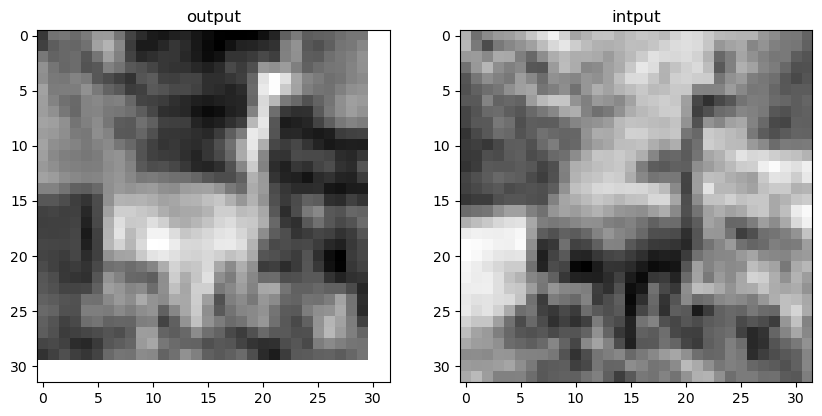

In [7]:
plt.figure(figsize=(10, 4.8))
ax1 = plt.subplot(1, 2, 1)
plt.title('output')
plt.imshow(output[0,0].detach(), cmap='gray')
plt.subplot(1,2,2, sharex=ax1, sharey=ax1)
plt.imshow(img.mean(0), cmap='gray')
plt.title('intput')
#plt.savefig('testconv.png')
plt.show()

# 卷积padding 填充

In [8]:
conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 32, 32]))

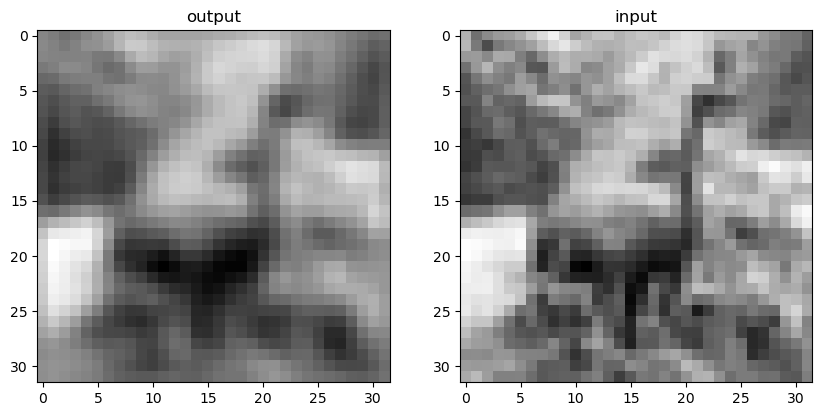

In [9]:
with torch.no_grad():
    conv.bias.zero_()
    
with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0)
    
output = conv(img.unsqueeze(0))
plt.figure(figsize=(10, 4.8))
ax1 = plt.subplot(1, 2, 1)
plt.title('output')
plt.imshow(output[0,0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)
plt.imshow(img.mean(0), cmap='gray')
plt.title('input')
plt.show()

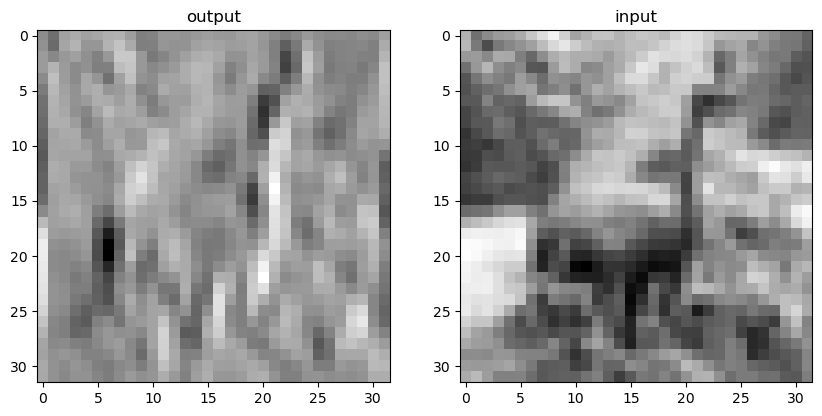

In [10]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)

with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                  [-1.0, 0.0, 1.0],
                                  [-1.0, 0.0, 1.0]])
    conv.bias.zero_()
    
output = conv(img.unsqueeze(0))
plt.figure(figsize=(10, 4.8))
ax1 = plt.subplot(1, 2, 1)
plt.title('output')
plt.imshow(output[0,0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)
plt.imshow(img.mean(0), cmap='gray')
plt.title('input')
plt.show()

# 下采样
1. 简单来说就是把图像的尺寸缩小，当然有下采样就有上采样，就是把图像的尺寸放大。
2. 关于把图像变小的一个方法就是池化（Pooling），池化主要有两种，一种是最大值池化（Max Pooling），一种是平均值池化（Average Pooling）。
##　带有步长的卷积
１.　步长就是卷积核在你原图上每一步移动的距离，　步长小提取的特征会更全面，不会遗漏太多信息。步长大，计算量会下降，但可能错失一些特征，通过增加步长，实现图像压缩效果。

In [ ]:
## 卷积网络


In [ ]:
model = nn.Sequential(
    nn.Conv2d(3,16,kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(16,8,kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(kernel_size=2),
    
    nn.Linear(8*8*8,32),
    nn.Tanh(),
    nn.Linear(32,2)
)

numel_list = [p.numel() for p in model.parameters()]
sum(numel_list),numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [64]:
class Net(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.conv1 = nn.Conv2d(3, 16, stride=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 8 ,kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(8*8*8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forword(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8*8*8)
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out


In [74]:
import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)    
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [86]:
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):

    for epoch in range(1, n_epochs + 1):
        loss_train  = 0.0

        for imgs, labels in train_loader:
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()

        if  epoch == 1 or epoch % 10 == 0:

            print(f'{datetime.datetime.now()} Epoch {epoch}, Training Loss: {loss_train / len(train_loader)}')


In [92]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,shuffle=True)

model = Net()
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
training_loop(
    n_epochs = 200,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

2025-04-26 08:04:07.977198 Epoch 1, Training Loss: 0.5642638686735919
2025-04-26 08:04:20.496833 Epoch 10, Training Loss: 0.3311943228647208
2025-04-26 08:04:33.703621 Epoch 20, Training Loss: 0.29048911244816084
2025-04-26 08:04:46.517260 Epoch 30, Training Loss: 0.26528641657464824
2025-04-26 08:04:59.199281 Epoch 40, Training Loss: 0.2444324947086869
2025-04-26 08:05:11.967321 Epoch 50, Training Loss: 0.23173686852500697
2025-04-26 08:05:24.703451 Epoch 60, Training Loss: 0.2176843164547993
2025-04-26 08:05:37.429142 Epoch 70, Training Loss: 0.20489696826145148
2025-04-26 08:05:50.128406 Epoch 80, Training Loss: 0.19332053825543943
2025-04-26 08:06:02.938256 Epoch 90, Training Loss: 0.1791840867157195
2025-04-26 08:06:15.645662 Epoch 100, Training Loss: 0.16687506228495555
2025-04-26 08:06:28.437390 Epoch 110, Training Loss: 0.15305788506557988
2025-04-26 08:06:41.177757 Epoch 120, Training Loss: 0.14417938672148498
2025-04-26 08:06:53.917205 Epoch 130, Training Loss: 0.131090245073

In [93]:
train_loader = torch.utils.data.DataLoader(
    cifar2, batch_size=64,shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    cifar2_val, batch_size=64,shuffle=True
)

def validate(model, train_loader  ,val_loader):
    for name, loader in [('train', train_loader), ('val', val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, 1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())
        print(f"Accuracy {name}, {correct/total}")

validate(model, train_loader, val_loader)

Accuracy train, 0.986
Accuracy val, 0.889


In [95]:
# 模型存储
torch.save(model.state_dict(), data_path+'/birds_and_airplanes.pt')

In [96]:
loaded_model = Net()
loaded_model.load_state_dict(torch.load(data_path+'/birds_and_airplanes.pt'))

<All keys matched successfully>

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available else torch.device('cpu')
device = torch.device('cpu')
print(device)

cpu


In [105]:
import datetime

import torch.utils 

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()
        if epoch % 10 == 0 or 1 == epoch:
            print(f'{datetime.datetime.now()} Epoch {epoch}, Loss: {loss_train/len(train_loader)}')

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

model = Net().to(device=device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(n_epochs=10, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader)

2025-04-26 08:19:29.023256 Epoch 1, Loss: 0.5946764458136954
2025-04-26 08:19:42.023255 Epoch 10, Loss: 0.334441563695859


In [106]:
# 添加模型宽度

class NetWidth(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(in_features=16*8*8, out_features=32)
        self.fc2 = nn.Linear(in_features=32, out_features=2)
    
    def forward(self, x):

        out  = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out  = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out  = out.view(-1, 16*8*8)
        out  = torch.tanh(self.fc1(out))
        out  = self.fc2(out)
        return out

In [107]:

class NetWidth(nn.Module):
    def __init__(self, n_channels):
        super().__init__()
        self.n_chans1 = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=self.n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=self.n_chans1, out_channels=self.n_chans1//2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(in_features=16*8*self.n_chans1//2, out_features=32)
        self.fc2 = nn.Linear(in_features=32, out_features=2)
    
    def forward(self, x):

        out  = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out  = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out  = out.view(-1, 16*8*8)
        out  = torch.tanh(self.fc1(out))
        out  = self.fc2(out)
        return out

# 正则化

In [ ]:
# regularization 正则化
# 1. 权重惩罚

In [ ]:
def training_loop_l2reg(n_epochs, optimizer, model, loss_fn, data_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in data_loader:
            imgs = imgs.to(device)
            lagels = labels.to(device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            # L2 regularization 权重惩罚项添加到总损失中
            l2_lambda = 0.001
            l2_norm = sum(p.pow(2.0).sum() for p in model.parameters())
            loss = loss + l2_lambda * l2_norm

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()
        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch}, Loss: {loss_train / len(data_loader)}')

# Dropout A Simple Way to Prevent Neural Networks from Overfitting 
1. 在训练环节中随机将权重归零丢弃一部分神经元，防止过拟合 

In [110]:
class NetDroput(nn.Module):
    def __init__(self, n_channels = 32):
        super().__init__()
        self.n_chansl = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(3, n_channels//2, kernel_size=3, padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8*8*n_channels//2, 32)
        self.fc2 = nn.Linear(32, 2)
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.tanh(self.conv2(x)), 2)
        out = self.conv2_dropout(out)

        out = out.view(-1, 8*8*self.n_chansl//2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [ ]:
# Batch Normalization : Accelerating Deep Network Training by Reducing Internal Covariate Shift

In [111]:
# 批量规划

class NetBatchNorm(nn.Module):
    def __init__(self, n_chansl=32):
        super().__init__()
        self.n_chansl = n_chansl
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_chansl, kernel_size=3, padding=1)
        self.conv1_batchnorm = nn.BatchNorm2d(num_features=n_chansl)
        self.conv2 = nn.Conv2d(in_channels=n_chansl, out_channels=n_chansl//2, kernel_size=3, padding=1)
        self.conv2_batchnorm = nn.BatchNorm2d(num_features=n_chansl//2)
        self.fc1 = nn.Linear(in_features=8*8*n_chansl//2, out_features=32)
        self.fc2 = nn.Linear(in_features=32, out_features=2)
    
    def forward(self, x):
        out = self.conv1_batchnorm(self.conv1(x))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = self.conv2_batchnorm(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, 8*8*self.n_chansl//2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

# 添加模型深度 reset模型
1. 添加跳跃连接

In [112]:
class ResNetTest(nn.Module):
    def __init__(self, n_channels =32):
        super().__init__()
        self.n_chans1 = n_channels
        self.conv1 = nn.Conv2d(3, n_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_channels, n_channels // 2,kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(n_channels // 2, n_channels // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_channels // 2, 32)
        self.fc2 = nn.Linear(32, 2)
    
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out1 = out
        out = F.max_pool2d(torch.relu(self.conv3(out)) + out1, 2)
        out = out.view(-1, 4 * 4 * self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [113]:
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
            
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Trainging loss {}'.format(datetime.datetime.now(), epoch, loss_train/len(train_loader)))
          

In [114]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

model = ResNetTest().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
            n_epochs = 100,
            optimizer = optimizer,
            model = model,
            loss_fn = loss_fn,
            train_loader = train_loader)

2025-04-26 12:35:27.888937 Epoch 1, Trainging loss 0.6299594800183728
2025-04-26 12:35:59.572387 Epoch 10, Trainging loss 0.31878445520522486
2025-04-26 12:36:32.848395 Epoch 20, Trainging loss 0.2715092600341056
2025-04-26 12:37:04.644594 Epoch 30, Trainging loss 0.23805294783821532
2025-04-26 12:37:32.886071 Epoch 40, Trainging loss 0.2097892832888919
2025-04-26 12:38:00.624406 Epoch 50, Trainging loss 0.18323189200489384
2025-04-26 12:38:28.490924 Epoch 60, Trainging loss 0.15843655672042992
2025-04-26 12:38:56.197233 Epoch 70, Trainging loss 0.13682371981821623
2025-04-26 12:39:23.930363 Epoch 80, Trainging loss 0.10875950132016164
2025-04-26 12:39:51.972333 Epoch 90, Trainging loss 0.09522596847526967
2025-04-26 12:40:19.839496 Epoch 100, Trainging loss 0.06991299379403425


In [115]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                           shuffle=True)

def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader),("val", val_loader)]:
        correct = 0
        total = 0
        
        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device=device)
                labels = labels.to(device=device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total += labels.shape[0]
                correct += int((predicted==labels).sum())
                
        print("Accuracy {}: {:.2f}".format(name, correct/total))

In [116]:
val_loader

In [117]:
validate(model, train_loader, val_loader)

Accuracy train: 0.84
Accuracy val: 0.81
